In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load Google Play Store Apps dataset
apps_df = pd.read_csv("../dataset/googleplaystore.csv")

# Load User Reviews dataset
reviews_df = pd.read_csv("../dataset/googleplaystore_user_reviews.csv")

print("Apps dataset loaded successfully!")
print("Apps dataset shape:", apps_df.shape)

print("\nUser reviews dataset loaded successfully!")
print("Reviews dataset shape:", reviews_df.shape)

print("\nApps dataset preview:")
display(apps_df.head())

print("\nUser reviews dataset preview:")
display(reviews_df.head())

Apps dataset loaded successfully!
Apps dataset shape: (10841, 13)

User reviews dataset loaded successfully!
Reviews dataset shape: (64295, 5)

Apps dataset preview:


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up



User reviews dataset preview:


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [4]:
# Inspect the structure of both datasets

print("===== APPS DATASET INFORMATION =====")
apps_df.info()

print("\n===== USER REVIEWS DATASET INFORMATION =====")
reviews_df.info()

===== APPS DATASET INFORMATION =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB

===== USER REVIEWS DATASET INFORMATION =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data

In [5]:
# Check missing values in both datasets

print("===== MISSING VALUES: APPS DATASET =====")
display(apps_df.isnull().sum().sort_values(ascending=False))

print("\n===== MISSING VALUES: USER REVIEWS DATASET =====")
display(reviews_df.isnull().sum().sort_values(ascending=False))

===== MISSING VALUES: APPS DATASET =====


Rating            1474
Current Ver          8
Android Ver          3
Content Rating       1
Type                 1
Size                 0
Reviews              0
Category             0
App                  0
Price                0
Installs             0
Last Updated         0
Genres               0
dtype: int64


===== MISSING VALUES: USER REVIEWS DATASET =====


Translated_Review         26868
Sentiment_Polarity        26863
Sentiment                 26863
Sentiment_Subjectivity    26863
App                           0
dtype: int64

In [6]:
# Create working copies of both datasets
apps = apps_df.copy()
reviews = reviews_df.copy()

# Check duplicates
print("Duplicate rows in Apps dataset:", apps.duplicated().sum())
print("Duplicate rows in Reviews dataset:", reviews.duplicated().sum())

# Remove completely duplicated rows
apps = apps.drop_duplicates().copy()
reviews = reviews.drop_duplicates().copy()

print("\nAfter removing duplicate rows:")
print("Apps dataset shape:", apps.shape)
print("Reviews dataset shape:", reviews.shape)

Duplicate rows in Apps dataset: 483
Duplicate rows in Reviews dataset: 33616

After removing duplicate rows:
Apps dataset shape: (10358, 13)
Reviews dataset shape: (30679, 5)


In [7]:
# Check duplicate app names
print("Duplicate App names:", apps["App"].duplicated().sum())

# Keep one record for each app
apps = apps.drop_duplicates(subset="App", keep="last").copy()

print("Apps dataset shape after removing duplicate App names:", apps.shape)

Duplicate App names: 698
Apps dataset shape after removing duplicate App names: (9660, 13)


In [8]:
# Handle missing values in Apps dataset

# Rating: fill with median
apps["Rating"] = apps["Rating"].fillna(apps["Rating"].median())

# Categorical columns: fill with most frequent value
for col in ["Current Ver", "Android Ver", "Content Rating", "Type"]:
    apps[col] = apps[col].fillna(apps[col].mode()[0])

print("Missing values handled in Apps dataset.")
display(apps.isnull().sum().sort_values(ascending=False).head(10))

Missing values handled in Apps dataset.


App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
dtype: int64

In [9]:
# Clean Installs column

apps["Installs"] = (
    apps["Installs"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)

apps["Installs"] = pd.to_numeric(
    apps["Installs"],
    errors="coerce"
)

print("Installs column cleaned successfully!")
display(apps[["App", "Installs"]].head())

Installs column cleaned successfully!


,App,Installs
0,Photo Editor & Candy Camera & Grid & ScrapBook,10000.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",5000000.0
3,Sketch - Draw & Paint,50000000.0
4,Pixel Draw - Number Art Coloring Book,100000.0
5,Paper flowers instructions,50000.0


In [10]:
# Clean Price column

apps["Price"] = (
    apps["Price"]
    .astype(str)
    .str.replace("$", "", regex=False)
)

apps["Price"] = pd.to_numeric(
    apps["Price"],
    errors="coerce"
)

print("Price column cleaned successfully!")
display(apps[["App", "Type", "Price"]].head())

Price column cleaned successfully!


,App,Type,Price
0,Photo Editor & Candy Camera & Grid & ScrapBook,Free,0.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",Free,0.0
3,Sketch - Draw & Paint,Free,0.0
4,Pixel Draw - Number Art Coloring Book,Free,0.0
5,Paper flowers instructions,Free,0.0


In [11]:
# Convert app size to MB

def convert_size(size):
    size = str(size)

    if size.endswith("M"):
        return float(size.replace("M", ""))

    elif size.endswith("k"):
        return float(size.replace("k", "")) / 1024

    return np.nan


apps["Size_MB"] = apps["Size"].apply(convert_size)

print("Size converted to MB successfully!")
display(apps[["App", "Size", "Size_MB"]].head(10))

Size converted to MB successfully!


,App,Size,Size_MB
0,Photo Editor & Candy Camera & Grid & ScrapBook,19M,19.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",8.7M,8.7
3,Sketch - Draw & Paint,25M,25.0
4,Pixel Draw - Number Art Coloring Book,2.8M,2.8
5,Paper flowers instructions,5.6M,5.6
6,Smoke Effect Photo Maker - Smoke Editor,19M,19.0
7,Infinite Painter,29M,29.0
8,Garden Coloring Book,33M,33.0
9,Kids Paint Free - Drawing Fun,3.1M,3.1
10,Text on Photo - Fonteee,28M,28.0


In [12]:
# Prepare reviews dataset for sentiment analysis

reviews = reviews.dropna(subset=["Translated_Review"]).copy()

print("Reviews remaining after removing missing review text:",
      reviews.shape)

display(reviews[["App", "Translated_Review"]].head())

Reviews remaining after removing missing review text: (29692, 5)


,App,Translated_Review
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...
1,10 Best Foods for You,This help eating healthy exercise regular basis
3,10 Best Foods for You,Works great especially going grocery store
4,10 Best Foods for You,Best idea us
5,10 Best Foods for You,Best way


In [13]:
# Final data cleaning verification

print("===== FINAL DATASET SUMMARY =====")
print("Apps dataset shape:", apps.shape)
print("Reviews dataset shape:", reviews.shape)

print("\nApps missing values:")
display(apps.isnull().sum().sort_values(ascending=False).head(10))

print("\nReviews missing values:")
display(reviews.isnull().sum().sort_values(ascending=False).head(10))

===== FINAL DATASET SUMMARY =====
Apps dataset shape: (9660, 14)
Reviews dataset shape: (29692, 5)

Apps missing values:


Size_MB           1228
Installs             1
Price                1
Rating               0
Category             0
App                  0
Size                 0
Reviews              0
Content Rating       0
Type                 0
dtype: int64


Reviews missing values:


App                       0
Translated_Review         0
Sentiment                 0
Sentiment_Polarity        0
Sentiment_Subjectivity    0
dtype: int64

In [14]:
# Handle remaining missing values in cleaned Apps dataset

# Fill Size_MB with median
apps["Size_MB"] = apps["Size_MB"].fillna(apps["Size_MB"].median())

# Fill Installs with median
apps["Installs"] = apps["Installs"].fillna(apps["Installs"].median())

# Fill Price with median
apps["Price"] = apps["Price"].fillna(apps["Price"].median())

print("Remaining missing values handled successfully!")

display(
    apps.isnull().sum()
    .sort_values(ascending=False)
    .head(10)
)

Remaining missing values handled successfully!


App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
dtype: int64

In [15]:
# Final verification of cleaned datasets

print("===== CLEANED APPS DATASET =====")
print("Shape:", apps.shape)
print("Total missing values:", apps.isnull().sum().sum())
print("Total duplicate rows:", apps.duplicated().sum())

print("\n===== CLEANED REVIEWS DATASET =====")
print("Shape:", reviews.shape)
print("Total missing values:", reviews.isnull().sum().sum())
print("Total duplicate rows:", reviews.duplicated().sum())

===== CLEANED APPS DATASET =====
Shape: (9660, 14)
Total missing values: 0
Total duplicate rows: 0

===== CLEANED REVIEWS DATASET =====
Shape: (29692, 5)
Total missing values: 0
Total duplicate rows: 0


In [16]:
# Category analysis

category_counts = apps["Category"].value_counts()

print("Number of apps by category:")
display(category_counts.to_frame(name="App Count"))

Number of apps by category:


,App Count
Category,
FAMILY,1906
GAME,926
TOOLS,829
BUSINESS,419
MEDICAL,396
PERSONALIZATION,376
PRODUCTIVITY,374
LIFESTYLE,369
FINANCE,345


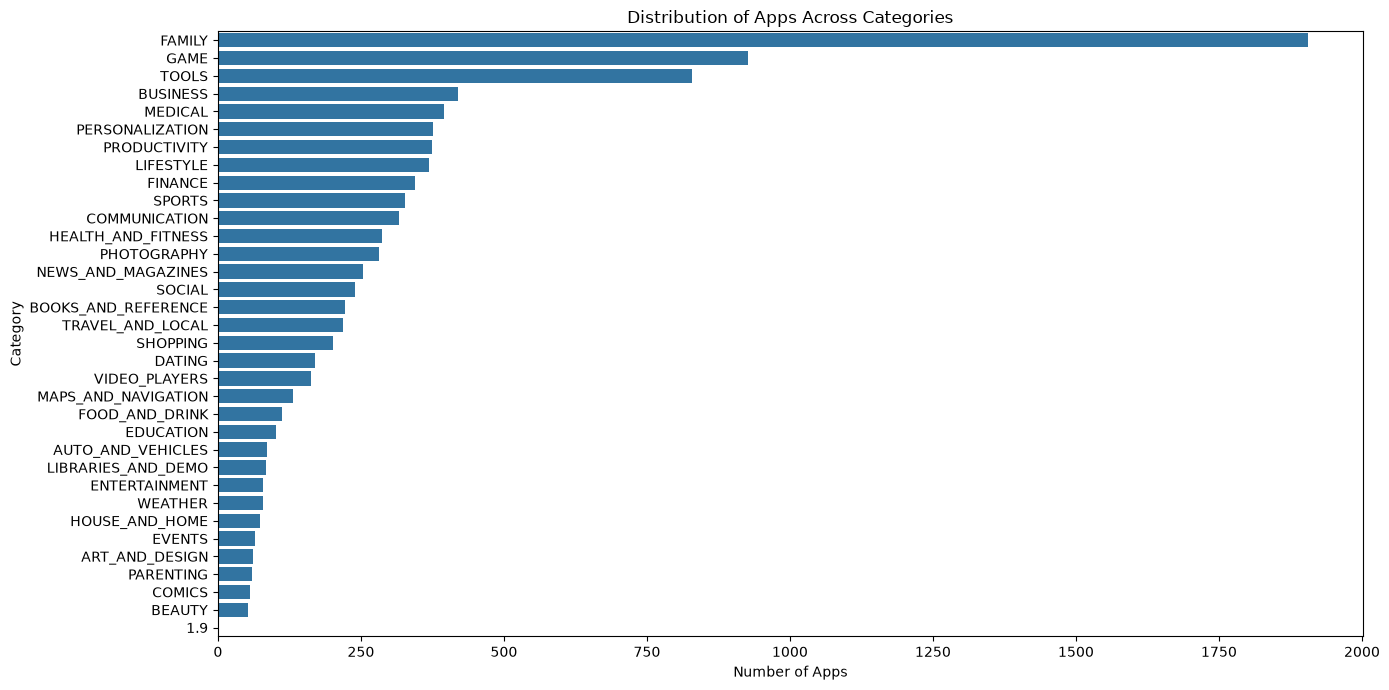

In [17]:
# Plot app distribution across categories

plt.figure(figsize=(14, 7))

sns.barplot(
    x=category_counts.values,
    y=category_counts.index
)

plt.title("Distribution of Apps Across Categories")
plt.xlabel("Number of Apps")
plt.ylabel("Category")
plt.tight_layout()

plt.show()

In [18]:
# Top 10 most saturated categories

top_categories = category_counts.head(10)

print("Top 10 most saturated app categories:")
display(top_categories.to_frame(name="App Count"))

Top 10 most saturated app categories:


,App Count
Category,
FAMILY,1906
GAME,926
TOOLS,829
BUSINESS,419
MEDICAL,396
PERSONALIZATION,376
PRODUCTIVITY,374
LIFESTYLE,369
FINANCE,345


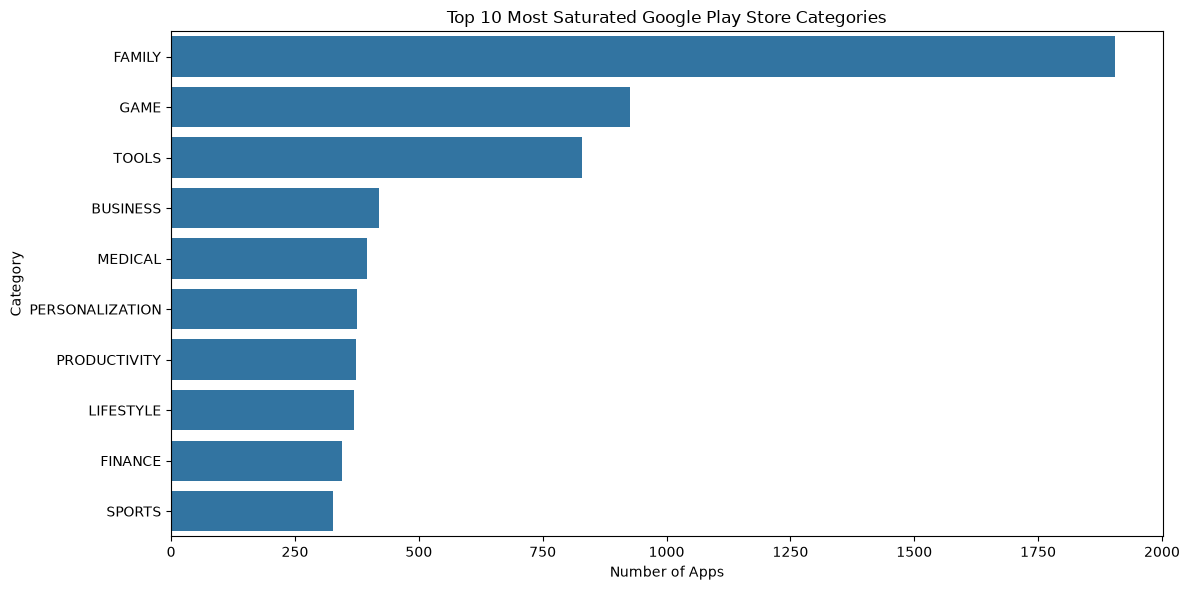

In [19]:
# Plot top 10 most saturated categories

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_categories.values,
    y=top_categories.index
)

plt.title("Top 10 Most Saturated Google Play Store Categories")
plt.xlabel("Number of Apps")
plt.ylabel("Category")
plt.tight_layout()

plt.show()

Valid rating records: 9659
Rating range: 1.0 to 5.0


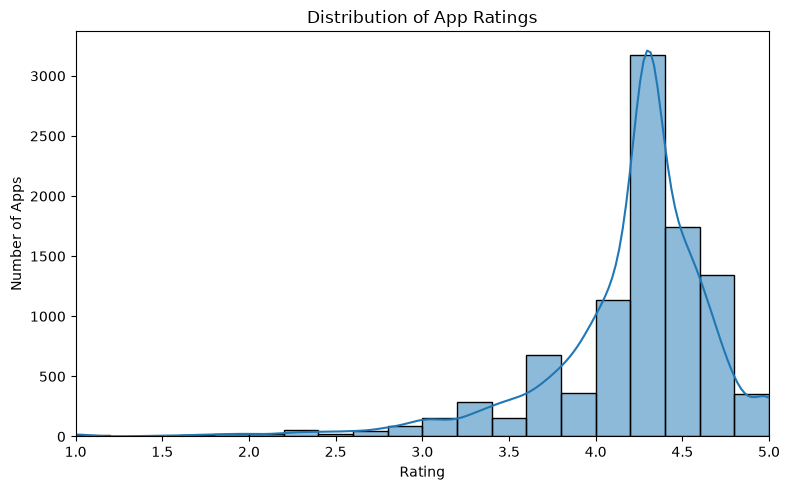

In [21]:
# Clean invalid rating values
apps["Rating"] = pd.to_numeric(apps["Rating"], errors="coerce")

# Keep only valid Google Play Store ratings (1 to 5)
apps.loc[~apps["Rating"].between(1, 5), "Rating"] = np.nan

# Remove rows with missing/invalid ratings for rating analysis
rating_data = apps.dropna(subset=["Rating"]).copy()

print("Valid rating records:", len(rating_data))
print("Rating range:", rating_data["Rating"].min(), "to", rating_data["Rating"].max())

# Rating Distribution
plt.figure(figsize=(8, 5))

sns.histplot(
    rating_data["Rating"],
    bins=20,
    kde=True
)

plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Apps")
plt.xlim(1, 5)

plt.tight_layout()

plt.savefig("../screenshots/08_rating_distribution.png", dpi=300)
plt.show()

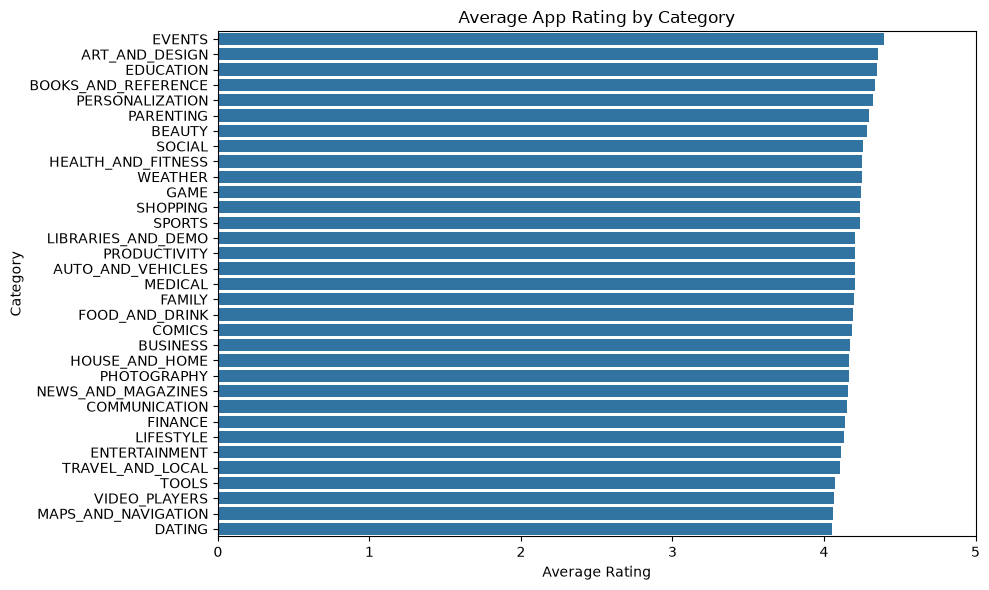

In [22]:
# Average Rating by Category

category_rating = (
    rating_data.groupby("Category")["Rating"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=category_rating.values,
    y=category_rating.index
)

plt.title("Average App Rating by Category")
plt.xlabel("Average Rating")
plt.ylabel("Category")
plt.xlim(0, 5)

plt.tight_layout()

plt.savefig("../screenshots/09_average_rating_by_category.png", dpi=300)
plt.show()

In [23]:
# Clean Size column

def convert_size(size):
    if pd.isna(size):
        return np.nan
    size = str(size).strip()

    if size.endswith("M"):
        return float(size.replace("M", ""))
    elif size.endswith("k"):
        return float(size.replace("k", "")) / 1024
    else:
        return np.nan

apps["Size_MB"] = apps["Size"].apply(convert_size)


# Clean Installs column

apps["Installs_Num"] = (
    apps["Installs"]
    .astype(str)
    .str.replace("+", "", regex=False)
    .str.replace(",", "", regex=False)
    .replace("nan", np.nan)
    .astype(float)
)

print("Size and Installs columns cleaned successfully!")
print("\nSize statistics:")
display(apps["Size_MB"].describe())

print("\nInstalls statistics:")
display(apps["Installs_Num"].describe())

Size and Installs columns cleaned successfully!

Size statistics:


count    8432.000000
mean       20.396984
std        21.828947
min         0.008301
25%         4.575000
50%        12.000000
75%        28.000000
max       100.000000
Name: Size_MB, dtype: float64


Installs statistics:


count    9.660000e+03
mean     7.792933e+06
std      5.376724e+07
min      0.000000e+00
25%      1.000000e+03
50%      1.000000e+05
75%      1.000000e+06
max      1.000000e+09
Name: Installs_Num, dtype: float64

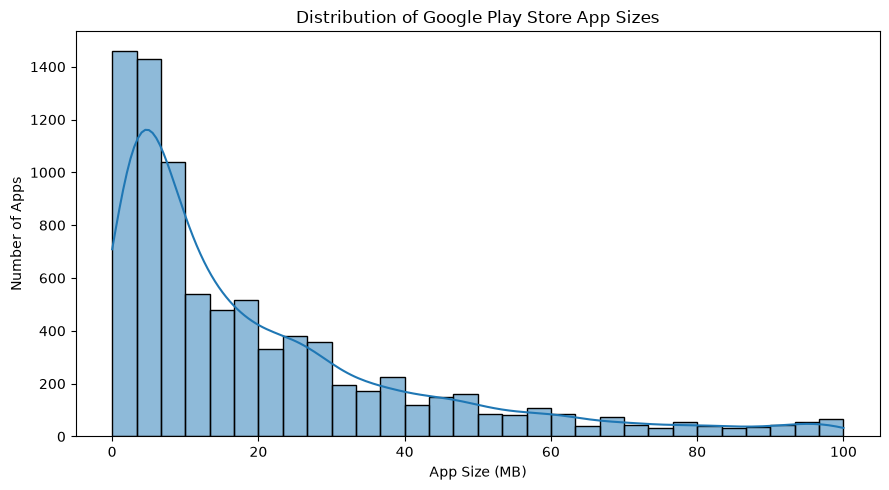

In [24]:
# Distribution of App Size

plt.figure(figsize=(9, 5))

sns.histplot(
    apps["Size_MB"].dropna(),
    bins=30,
    kde=True
)

plt.title("Distribution of Google Play Store App Sizes")
plt.xlabel("App Size (MB)")
plt.ylabel("Number of Apps")

plt.tight_layout()

plt.savefig("../screenshots/10_app_size_distribution.png", dpi=300)
plt.show()

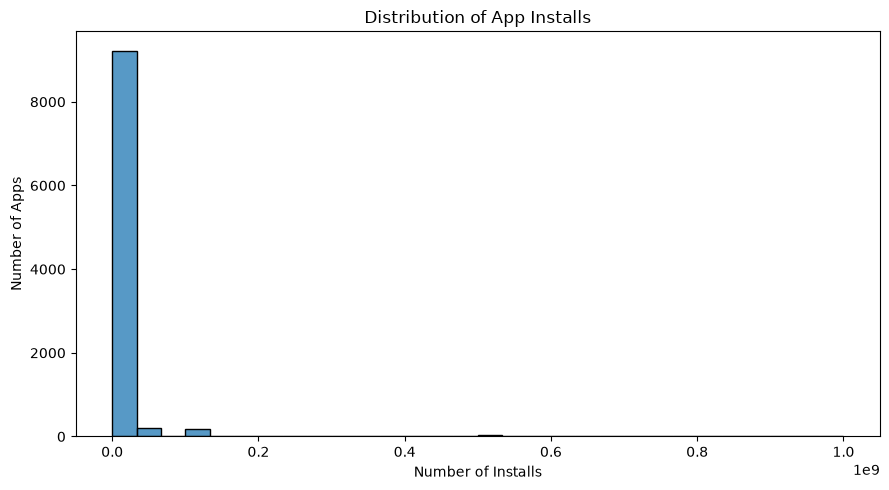

In [25]:
# Distribution of App Installs

plt.figure(figsize=(9, 5))

sns.histplot(
    apps["Installs_Num"].dropna(),
    bins=30
)

plt.title("Distribution of App Installs")
plt.xlabel("Number of Installs")
plt.ylabel("Number of Apps")

plt.tight_layout()

plt.savefig("../screenshots/11_installs_distribution.png", dpi=300)
plt.show()

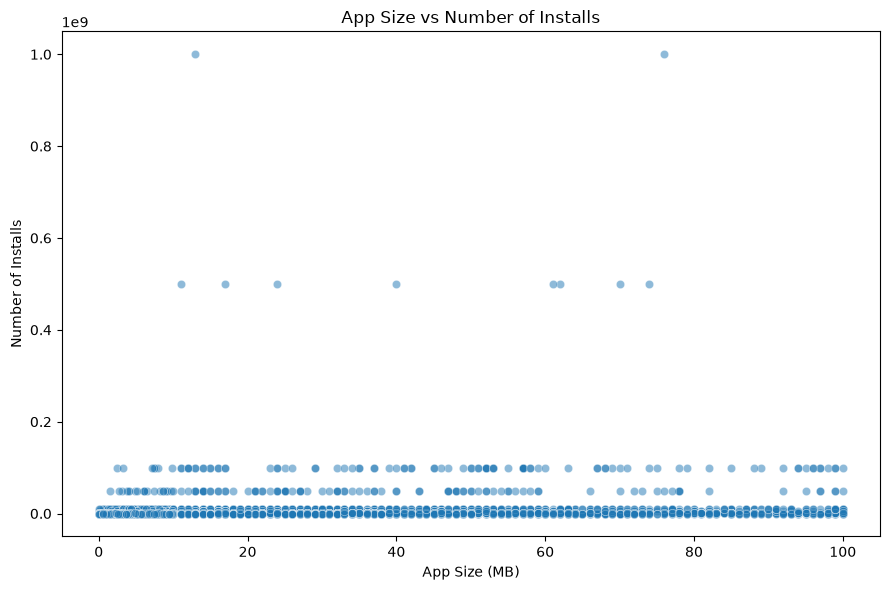

In [26]:
# App Size vs Number of Installs

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=apps,
    x="Size_MB",
    y="Installs_Num",
    alpha=0.5
)

plt.title("App Size vs Number of Installs")
plt.xlabel("App Size (MB)")
plt.ylabel("Number of Installs")

plt.tight_layout()

plt.savefig("../screenshots/12_size_vs_installs.png", dpi=300)
plt.show()

In [27]:
# Pricing Analysis

# Convert Price to numeric
apps["Price_Num"] = pd.to_numeric(apps["Price"], errors="coerce")

# Free vs Paid
apps["App_Type"] = apps["Price_Num"].apply(
    lambda x: "Free" if x == 0 else "Paid"
)

print("Free vs Paid App Distribution:")
display(apps["App_Type"].value_counts())

Free vs Paid App Distribution:


App_Type
Free    8906
Paid     754
Name: count, dtype: int64

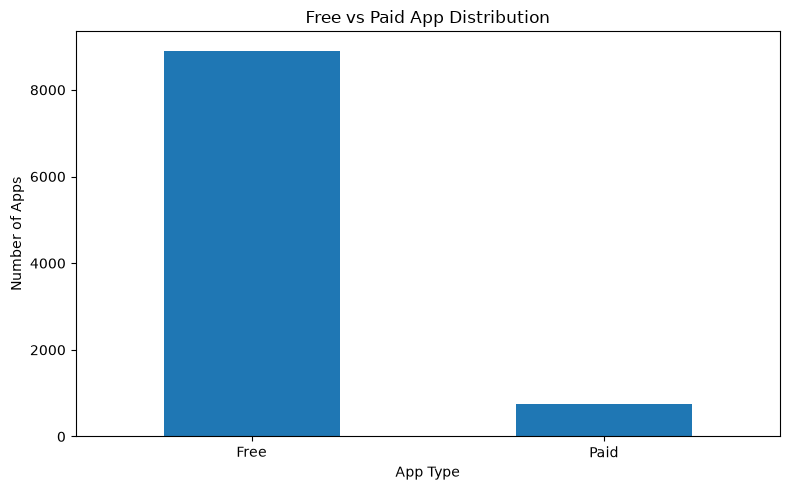

In [28]:
# Free vs Paid App Distribution

plt.figure(figsize=(8, 5))

apps["App_Type"].value_counts().plot(
    kind="bar"
)

plt.title("Free vs Paid App Distribution")
plt.xlabel("App Type")
plt.ylabel("Number of Apps")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("../screenshots/13_free_vs_paid.png", dpi=300)
plt.show()

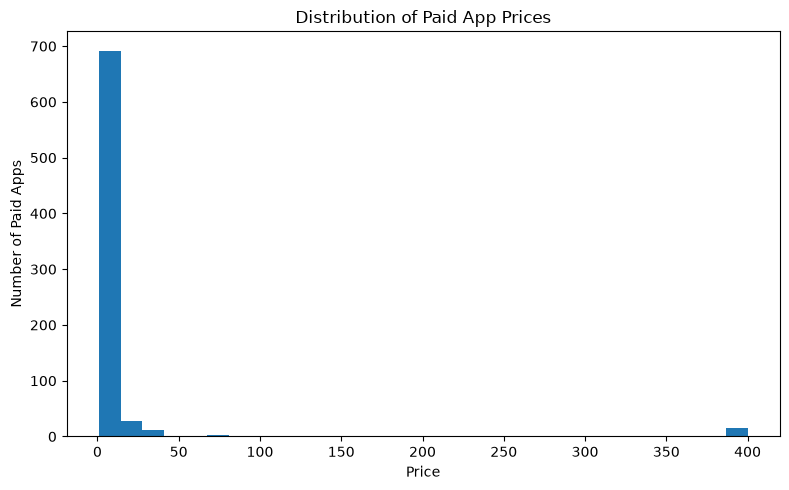

In [29]:
# Paid App Price Distribution

paid_apps = apps[apps["App_Type"] == "Paid"].copy()

plt.figure(figsize=(8, 5))

plt.hist(paid_apps["Price_Num"], bins=30)

plt.title("Distribution of Paid App Prices")
plt.xlabel("Price")
plt.ylabel("Number of Paid Apps")

plt.tight_layout()
plt.savefig("../screenshots/14_paid_price_distribution.png", dpi=300)
plt.show()

In [30]:
# Revenue Estimation

# Convert installs such as "10,000+" into numeric values
apps["Installs_Num"] = (
    apps["Installs"]
    .astype(str)
    .str.replace("+", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

# Estimate revenue for paid apps
apps["Estimated_Revenue"] = (
    apps["Price_Num"] * apps["Installs_Num"]
)

# Revenue by category
revenue_by_category = (
    apps[apps["App_Type"] == "Paid"]
    .groupby("Category")["Estimated_Revenue"]
    .sum()
    .sort_values(ascending=False)
)

print("Estimated Revenue by Category:")
display(revenue_by_category.head(10))

Estimated Revenue by Category:


Category
FAMILY             1.156808e+08
LIFESTYLE          5.758394e+07
GAME               4.068864e+07
FINANCE            2.572668e+07
PHOTOGRAPHY        8.547768e+06
PERSONALIZATION    6.796948e+06
MEDICAL            5.956237e+06
TOOLS              5.464821e+06
SPORTS             4.706212e+06
PRODUCTIVITY       4.313375e+06
Name: Estimated_Revenue, dtype: float64

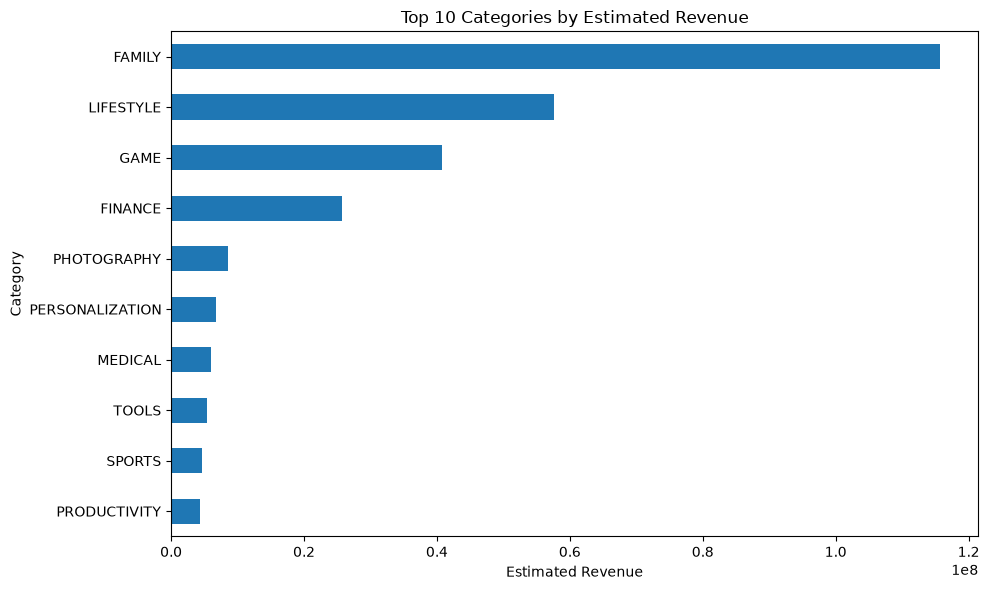

In [31]:
# Top 10 Categories by Estimated Revenue

plt.figure(figsize=(10, 6))

revenue_by_category.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Categories by Estimated Revenue")
plt.xlabel("Estimated Revenue")
plt.ylabel("Category")
plt.tight_layout()

plt.savefig("../screenshots/15_revenue_by_category.png", dpi=300)
plt.show()

In [32]:
# Sentiment Analysis - Review Data Check

print("Review dataset shape:", reviews.shape)

print("\nReview columns:")
print(reviews.columns.tolist())

print("\nSample reviews:")
display(reviews[["App", "Translated_Review"]].head(10))

Review dataset shape: (29692, 5)

Review columns:
['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity', 'Sentiment_Subjectivity']

Sample reviews:


,App,Translated_Review
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...
1,10 Best Foods for You,This help eating healthy exercise regular basis
3,10 Best Foods for You,Works great especially going grocery store
4,10 Best Foods for You,Best idea us
5,10 Best Foods for You,Best way
6,10 Best Foods for You,Amazing
8,10 Best Foods for You,"Looking forward app,"
9,10 Best Foods for You,It helpful site ! It help foods get !
10,10 Best Foods for You,good you.
11,10 Best Foods for You,Useful information The amount spelling errors ...


In [33]:
# TextBlob Sentiment Analysis

def get_sentiment(text):
    if pd.isna(text):
        return "Neutral"
    
    polarity = TextBlob(str(text)).sentiment.polarity
    
    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"


reviews["TextBlob_Sentiment"] = reviews["Translated_Review"].apply(get_sentiment)

print("TextBlob sentiment classification completed successfully!")

print("\nSentiment Distribution:")
display(reviews["TextBlob_Sentiment"].value_counts())

TextBlob sentiment classification completed successfully!

Sentiment Distribution:


TextBlob_Sentiment
Positive    19014
Negative     6322
Neutral      4356
Name: count, dtype: int64

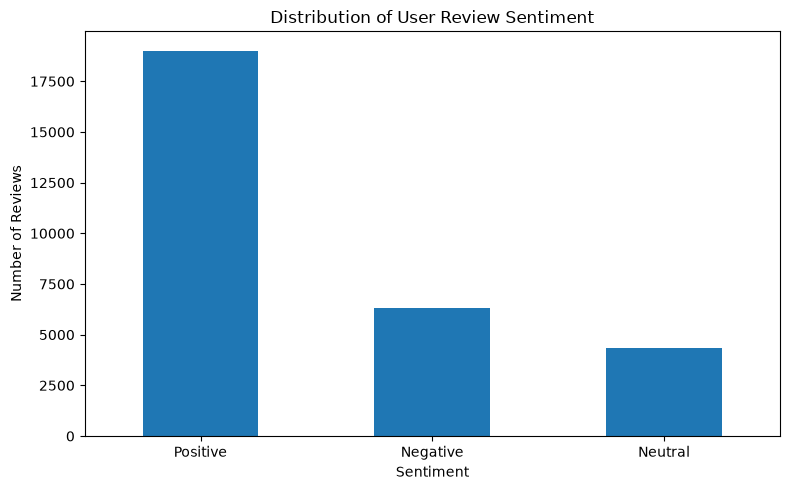

In [34]:
# Sentiment Distribution

sentiment_counts = reviews["TextBlob_Sentiment"].value_counts()

plt.figure(figsize=(8, 5))

sentiment_counts.plot(kind="bar")

plt.title("Distribution of User Review Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig("../screenshots/16_sentiment_distribution.png", dpi=300)
plt.show()

In [35]:
# Merge reviews with app categories

reviews_with_category = reviews.merge(
    apps[["App", "Category"]],
    on="App",
    how="left"
)

print("Reviews with category shape:", reviews_with_category.shape)

print("\nMissing categories:")
print(reviews_with_category["Category"].isna().sum())

display(
    reviews_with_category[
        ["App", "Category", "TextBlob_Sentiment"]
    ].head(10)
)

Reviews with category shape: (29692, 7)

Missing categories:
1442


,App,Category,TextBlob_Sentiment
0,10 Best Foods for You,HEALTH_AND_FITNESS,Positive
1,10 Best Foods for You,HEALTH_AND_FITNESS,Positive
2,10 Best Foods for You,HEALTH_AND_FITNESS,Positive
3,10 Best Foods for You,HEALTH_AND_FITNESS,Positive
4,10 Best Foods for You,HEALTH_AND_FITNESS,Positive
5,10 Best Foods for You,HEALTH_AND_FITNESS,Positive
6,10 Best Foods for You,HEALTH_AND_FITNESS,Neutral
7,10 Best Foods for You,HEALTH_AND_FITNESS,Neutral
8,10 Best Foods for You,HEALTH_AND_FITNESS,Positive
9,10 Best Foods for You,HEALTH_AND_FITNESS,Positive


In [36]:
# Sentiment Analysis by App Category

# Keep only reviews with a valid category
category_sentiment = reviews_with_category.dropna(
    subset=["Category"]
).copy()

# Calculate percentage of each sentiment within every category
sentiment_by_category = pd.crosstab(
    category_sentiment["Category"],
    category_sentiment["TextBlob_Sentiment"],
    normalize="index"
) * 100

# Add total review count
review_counts = category_sentiment["Category"].value_counts()

sentiment_by_category["Total_Reviews"] = review_counts

# Display results
print("Sentiment by App Category:")
display(
    sentiment_by_category.sort_values(
        "Positive",
        ascending=False
    ).head(10)
)

Sentiment by App Category:


TextBlob_Sentiment,Negative,Neutral,Positive,Total_Reviews
Category,,,,
COMICS,2.222222,11.111111,86.666667,45
AUTO_AND_VEHICLES,6.007067,12.720848,81.272085,283
EVENTS,10.256410,10.897436,78.846154,156
HEALTH_AND_FITNESS,10.980876,11.165947,77.853177,1621
EDUCATION,12.396694,13.429752,74.173554,484
FOOD_AND_DRINK,13.379074,12.521441,74.099485,583
LIBRARIES_AND_DEMO,15.361446,13.253012,71.385542,332
PARENTING,8.984375,20.312500,70.703125,256
PERSONALIZATION,14.568158,15.920916,69.510926,961


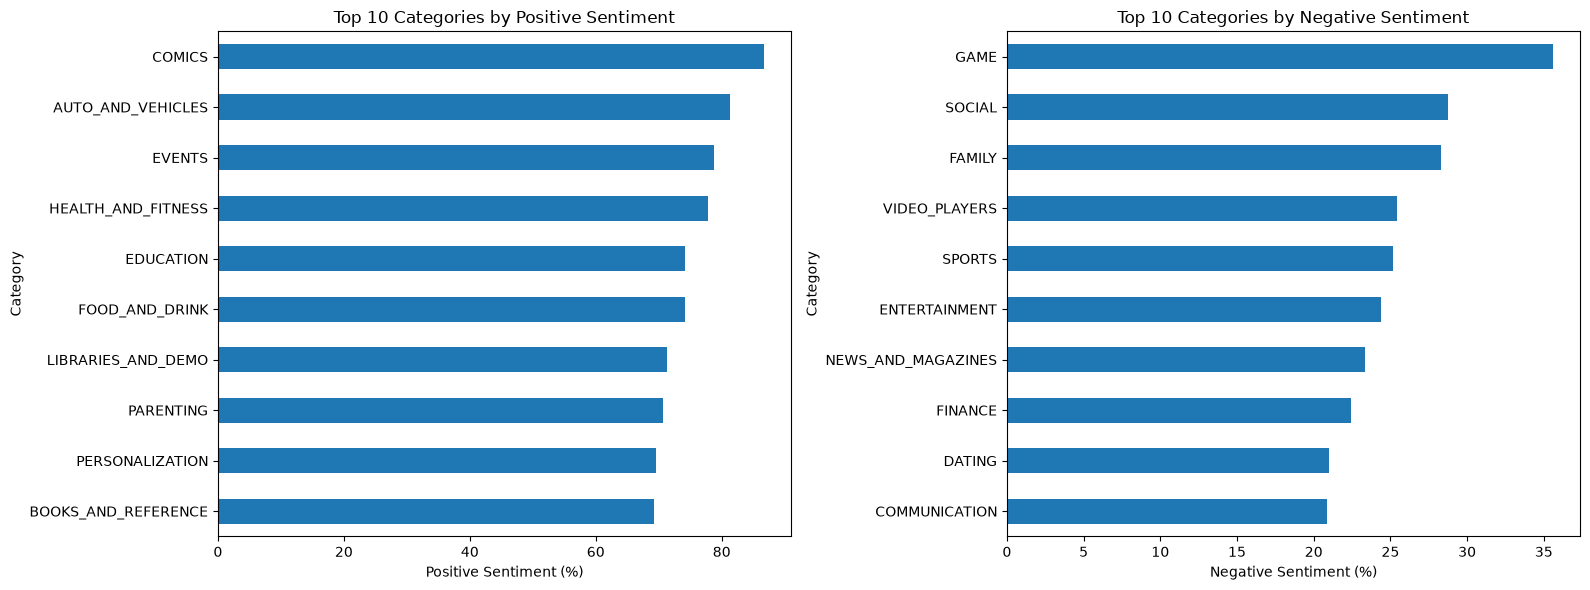

In [37]:
# Top 10 Categories by Positive and Negative Sentiment

top_positive = sentiment_by_category.sort_values(
    "Positive",
    ascending=False
).head(10)

top_negative = sentiment_by_category.sort_values(
    "Negative",
    ascending=False
).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Positive sentiment
top_positive["Positive"].sort_values().plot(
    kind="barh",
    ax=axes[0]
)

axes[0].set_title("Top 10 Categories by Positive Sentiment")
axes[0].set_xlabel("Positive Sentiment (%)")
axes[0].set_ylabel("Category")

# Negative sentiment
top_negative["Negative"].sort_values().plot(
    kind="barh",
    ax=axes[1]
)

axes[1].set_title("Top 10 Categories by Negative Sentiment")
axes[1].set_xlabel("Negative Sentiment (%)")
axes[1].set_ylabel("Category")

plt.tight_layout()

plt.savefig(
    "../screenshots/17_sentiment_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [38]:
import plotly.express as px

# Interactive category analysis
interactive_data = (
    sentiment_by_category
    .reset_index()
    .sort_values("Positive", ascending=False)
)

fig = px.bar(
    interactive_data.head(15),
    x="Category",
    y=["Positive", "Neutral", "Negative"],
    title="Interactive Sentiment Analysis by App Category",
    barmode="group",
    labels={
        "value": "Sentiment (%)",
        "variable": "Sentiment"
    }
)

fig.update_layout(
    xaxis_tickangle=-45,
    height=600
)

fig.show()

## Conclusion – Data-Driven Insights for a New App

1. **Focus on high-demand categories:** The analysis shows that FAMILY, GAME, and TOOLS are among the most represented categories in the Google Play Store. A developer should study these high-demand categories while identifying a specific underserved niche.

2. **Prioritize user experience and ratings:** Most apps have ratings concentrated around 4.0–4.5, indicating that maintaining a high rating is important for competitiveness. Developers should focus on app quality, reliability, and user satisfaction.

3. **Use sentiment to guide product decisions:** User reviews are predominantly positive, while categories such as GAME and SOCIAL show comparatively higher negative sentiment. A new app should analyze user feedback continuously and address common complaints to improve retention and reputation.